# Model Training for 4 Crops: TCN-MLP
This notebook trains the 4-crop (Maize, Rice, Cassava, Yam) robust TCN-MLP architecture.

## 1. Setup & Data Loading
We load the preprocessed matching data, extract the 3D 12-month temporal sequence block spanning our selected climate features (GDD, rainfall, humidity), and structure our categorical targets.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input, Model, optimizers, regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import json
import time

print(f'TensorFlow version: {tf.__version__}')

df = pd.read_csv('../data/processed_dataset.csv')

# Drop empty yields
df = df.dropna(subset=['Yield_kg_per_ha'])
print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')

# Dynamically calculate Growing Degree Days (GDD) Base 10
for month in range(1, 13):
    max_col = f'T2M_MAX_m{month}'
    min_col = f'T2M_MIN_m{month}'
    if max_col in df.columns and min_col in df.columns:
        t_avg = (df[max_col] + df[min_col]) / 2.0
        df[f'GDD_m{month}'] = np.maximum(0, t_avg - 10)

# Feature Extraction
exclude_cols = {'Yield_kg_per_ha', 'Region', 'Crop', 'Year', 'Unnamed: 0', 'seq_months'}
feature_cols = [col for col in df.columns if col not in exclude_cols]

unique_features = ['GDD', 'PRECTOTCORR', 'RH2M']
n_features = len(unique_features)
n_samples = df.shape[0]
n_months = 12

print(f'Number of unique climate features: {n_features}')

X_seq = np.zeros((n_samples, n_months, n_features))
for month in range(1, n_months + 1):
    for feat_idx, feat_name in enumerate(unique_features):
        col_name = f'{feat_name}_m{month}'
        if col_name in df.columns:
            X_seq[:, month-1, feat_idx] = df[col_name].values

y_raw = df['Yield_kg_per_ha'].values
region_names = df['Region'].values
crop_names = df['Crop'].values
years = df['Year'].values

region_to_id = {r: i for i, r in enumerate(sorted(np.unique(region_names)))}
crop_to_id = {c: i for i, c in enumerate(sorted(np.unique(crop_names)))}

region_ids = np.array([region_to_id[r] for r in region_names])
crop_ids = np.array([crop_to_id[c] for c in crop_names])

print(f"Regions mapping: {region_to_id}")
print(f"Crop mapping: {crop_to_id}")


TensorFlow version: 2.20.0
Dataset shape: (600, 208)
Missing values: 0
Number of unique climate features: 3
Regions mapping: {'North-Central': 0, 'North-East': 1, 'North-West': 2, 'South-East': 3, 'South-South': 4, 'South-West': 5}
Crop mapping: {'Cassava': 0, 'Maize': 1, 'Rice': 2, 'Yam': 3}


## 2. Feature Scaling & Train-Test Split
This step mathematically standardizes the unrolled climate variables symmetrically, normalizes spatial Time/Year inputs, and utilizes `train_test_split` to create a robust stratified train/test holdout matrix cleanly covering all Crop clusters without bleeding bias.

In [2]:
# Standardize Data
scaler_X = StandardScaler()
X_seq_flat = X_seq.reshape(-1, n_features)
X_seq_scaled = scaler_X.fit_transform(X_seq_flat).reshape(X_seq.shape)

epsilon = 1e-6
y_log = np.log(y_raw + epsilon)

# Year interaction terms
year_data = years.reshape(-1, 1)
min_year = 1999
max_year_span = 24.0 # Range: 1999-2023 

year_normalized = (year_data - min_year) / max_year_span
year_poly = np.column_stack([year_normalized, year_normalized**2, year_normalized**3])

N_REGIONS = 6
N_CROPS = 4

region_year = np.zeros((len(years), N_REGIONS))
for i in range(N_REGIONS):
    region_year[:, i] = (region_ids == i).astype(float) * year_normalized.flatten()

crop_year = np.zeros((len(years), N_CROPS))
for i in range(N_CROPS):
    crop_year[:, i] = (crop_ids == i).astype(float) * year_normalized.flatten()

year_extended = np.column_stack([year_poly, region_year, crop_year])
year_scaler = StandardScaler()
year_scaled = year_scaler.fit_transform(year_extended)
n_year_features = year_extended.shape[1]

# Train-test Split 
n_total = len(X_seq_scaled)
n_test = int(0.15 * n_total)

# Simplified stratification to avoid singleton classes in 4-crop expansion
strat_key_full = np.array([f"{r}_{c}" for r, c in zip(region_ids, crop_ids)])

np.random.seed(42)
train_indices, test_indices = train_test_split(
    np.arange(n_total), test_size=n_test, stratify=strat_key_full, random_state=42
)

X_full, y_full, y_full_raw = X_seq_scaled[train_indices], y_log[train_indices], y_raw[train_indices]
X_test, y_test, y_test_raw = X_seq_scaled[test_indices], y_log[test_indices], y_raw[test_indices]
region_ids_full, region_ids_test = region_ids[train_indices], region_ids[test_indices]
crop_ids_full, crop_ids_test = crop_ids[train_indices], crop_ids[test_indices]
year_train, year_test = year_scaled[train_indices], year_scaled[test_indices]

print(f"Train size: {len(X_full)}, Test size: {len(X_test)}")
print(f"Sequence Features: {n_features}, Year Details: {n_year_features}")

unique_regions, region_counts = np.unique(region_ids_full, return_counts=True)
region_weights = len(region_ids_full) / region_counts
region_weights = region_weights / region_weights.max()
region_weights_map = {r: w for r, w in zip(unique_regions, region_weights)}

Train size: 510, Test size: 90
Sequence Features: 3, Year Details: 13


## 3. Data Augmentation & Model Architecture Definition
We introduce the `mixup_augment` function which handles synthesizing new interpolated instances out of minority regional reports preventing class imbalance. 
We then define the full `TCN-MLP` model including our `L2=1e-3` regularization, `Dropout=0.25`, temporal `MultiHeadAttention`, categorical Embedding Layers, and initialize it over a specialized `Huber` loss to handle scaling anomalies.

In [3]:
def mixup_augment(X, y, r_ids, c_ids, yr_in, alpha=0.3, n_aug=40):
    n_samples = len(X)
    X_aug_list, y_aug_list = [X], [y]
    r_aug_list, c_aug_list, yr_aug_list = [r_ids], [c_ids], [yr_in]
    
    for _ in range(n_aug):
        idx1, idx2 = np.random.randint(0, n_samples, n_samples), np.random.randint(0, n_samples, n_samples)
        lam = np.random.beta(alpha, alpha, (n_samples, 1, 1))
        lam_1d, lam_2d = lam.ravel(), lam.reshape(-1, 1)
        
        X_aug_list.append(lam * X[idx1] + (1 - lam) * X[idx2])
        y_aug_list.append(lam_1d * y[idx1] + (1 - lam_1d) * y[idx2])
        r_aug_list.append(r_ids[idx1])
        c_aug_list.append(c_ids[idx1])
        yr_aug_list.append(lam_2d * yr_in[idx1] + (1 - lam_2d) * yr_in[idx2])
        
    return np.vstack(X_aug_list), np.concatenate(y_aug_list), np.concatenate(r_aug_list), np.concatenate(c_aug_list), np.vstack(yr_aug_list)

def build_model(l2_reg=1e-3, dropout=0.25):
    lr = 8e-4
    n_feat = 17 # Make sure it matches our n_features count dynamically
    
    X_input = layers.Input(shape=(12, n_features), name='seq_input')
    region_input = layers.Input(shape=(1,), dtype=tf.int32, name='region_input')
    crop_input = layers.Input(shape=(1,), dtype=tf.int32, name='crop_input')
    year_input = layers.Input(shape=(n_year_features,), dtype=tf.float32, name='year_input')
    
    tcn_filters = 28
    
    x_tcn = layers.GaussianNoise(0.05)(X_input)
    x = layers.Conv1D(tcn_filters, 3, padding='causal', activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x_tcn)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    
    x_attn = layers.MultiHeadAttention(num_heads=4, key_dim=8)(x, x)
    x = layers.Add()([x, x_attn])
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    
    # 6 Regions
    region_embed = layers.Embedding(input_dim=N_REGIONS, output_dim=max(6, int(tcn_filters // 4)))(region_input)
    region_flat = layers.Flatten()(region_embed)
    
    # 4 Crops
    crop_embed = layers.Embedding(input_dim=N_CROPS, output_dim=max(4, int(tcn_filters // 8)))(crop_input)
    crop_flat = layers.Flatten()(crop_embed)
    
    merged = layers.Concatenate()([x, region_flat, crop_flat, year_input])
    
    dense_1 = layers.Dense(20, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(merged)
    dense_1 = layers.BatchNormalization()(dense_1)
    dense_1 = layers.Dropout(dropout)(dense_1)
    dense_2 = layers.Dense(14, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(dense_1)
    output = layers.Dense(1, activation='linear', bias_initializer=keras.initializers.Constant(7.5))(dense_2)
    
    model = Model(inputs=[X_input, region_input, crop_input, year_input], outputs=output)
    model.compile(optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=2e-4), loss=tf.keras.losses.Huber(delta=0.2), metrics=['mae'])
    
    return model


## 4. Train Model and Check Overfitting (Learning Curves)
Applies symmetric data augmentation tightly to the training split, executes the training phase, plots the historical Traing/Val convergence to mathematically visually verify **no overfitting is occurring**, tests general unseen performance metrics explicitly (Train/Val/Test), and ultimately saves out the `.keras` architecture file.

In [4]:
# Strict Pipeline: 5-Fold CV + Augmentation + Locked Test Set
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import copy

BEST_L2 = 1e-3
BEST_DROPOUT = 0.25
BEST_N_AUG = 40

print('='*80)
print('BEST CONFIGURATION: 5-FOLD CROSS-VALIDATION')
print('='*80)
print('Hyperparameters:')
print('  L2 Regularization: 1e-3')
print('  Dropout: 0.25')
print('  Mixup Augmentation: n_aug=40')
print('  Learning Rate: 8e-4 (cosine annealing)')
print('  Weight Decay: 2e-4')
print('='*80 + '\n')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_train_r2_list = []
cv_val_r2_list = []
cv_test_r2_list = []
cv_val_mae_list = []
cv_models = []

strat_key = region_ids_full * 10 + crop_ids_full
start_cv = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key), 1):
    fold_start = time.time()
    
    # 1. Split training data into Train and Val folds
    X_train_f = X_full[train_idx]
    y_train_f = y_full[train_idx]
    y_train_raw_f = y_full_raw[train_idx]
    r_train_f = region_ids_full[train_idx]
    c_train_f = crop_ids_full[train_idx]
    yr_train_f = year_train[train_idx]
    
    X_val_f = X_full[val_idx]
    y_val_f = y_full[val_idx]
    y_val_raw_f = y_full_raw[val_idx]
    r_val_f = region_ids_full[val_idx]
    c_val_f = crop_ids_full[val_idx]
    yr_val_f = year_train[val_idx]
    
    # 2. Augment ONLY the train fold
    X_aug_f, y_aug_f, r_aug_f, c_aug_f, yr_aug_f = mixup_augment(
        X_train_f, y_train_f, r_train_f, c_train_f, yr_train_f, 
        alpha=0.3, n_aug=BEST_N_AUG
    )
    sample_weights_f = np.array([region_weights_map.get(r, 1.0) for r in r_aug_f.ravel()])
    
    # 3. Build fresh model
    fold_model = build_model(l2_reg=BEST_L2, dropout=BEST_DROPOUT)
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=0)
    cosine_cb = keras.callbacks.LearningRateScheduler(lambda epoch: 8e-4 * 0.5 * (1 + np.cos(np.pi * epoch / 150)))
    
    # 4. Train model using Val fold for early stopping
    history = fold_model.fit(
        [X_aug_f, r_aug_f, c_aug_f, yr_aug_f], y_aug_f,
        sample_weight=sample_weights_f,
        validation_data=([X_val_f, r_val_f, c_val_f, yr_val_f], y_val_f),
        epochs=150, batch_size=16,
        callbacks=[early_stop, cosine_cb],
        verbose=0
    )
    
    # 5. Evaluate Train fold R²
    y_train_pred_log = fold_model.predict([X_train_f, r_train_f, c_train_f, yr_train_f], verbose=0).ravel()
    y_train_pred = np.exp(y_train_pred_log)
    train_r2 = r2_score(y_train_raw_f, y_train_pred)
    
    # 6. Evaluate Val fold R² and MAE
    y_val_pred_log = fold_model.predict([X_val_f, r_val_f, c_val_f, yr_val_f], verbose=0).ravel()
    y_val_pred = np.exp(y_val_pred_log)
    val_r2 = r2_score(y_val_raw_f, y_val_pred)
    val_mae = mean_absolute_error(y_val_raw_f, y_val_pred)
    
    # 7. Evaluate Test set R² (independent test set)
    y_test_pred_log = fold_model.predict([X_test, region_ids_test, crop_ids_test, year_test], verbose=0).ravel()
    y_test_pred = np.exp(y_test_pred_log)
    test_r2 = r2_score(y_test_raw, y_test_pred)
    
    cv_train_r2_list.append(train_r2)
    cv_val_r2_list.append(val_r2)
    cv_test_r2_list.append(test_r2)
    cv_val_mae_list.append(val_mae)
    cv_models.append(fold_model)
    
    elapsed = time.time() - fold_start
    print(f'Fold {fold}: Train R²={train_r2:.4f}, Val R²={val_r2:.4f}, Test R²={test_r2:.4f}, Val MAE={val_mae:.1f} ({elapsed:.0f}s)')

total_cv_time = time.time() - start_cv

print(f'\n' + '='*80)
print('5-FOLD CROSS-VALIDATION RESULTS')
print('='*80)
print(f'Training R²:   {np.mean(cv_train_r2_list):.4f} ± {np.std(cv_train_r2_list):.4f}')
print(f'Validation R²: {np.mean(cv_val_r2_list):.4f} ± {np.std(cv_val_r2_list):.4f}')
print(f'Test R²:       {np.mean(cv_test_r2_list):.4f} ± {np.std(cv_test_r2_list):.4f}')
print(f'Validation MAE: {np.mean(cv_val_mae_list):.1f} ± {np.std(cv_val_mae_list):.1f} kg/ha')
print(f'\nTrain-Test Gap: {(np.mean(cv_train_r2_list) - np.mean(cv_test_r2_list))*100:.1f}%')
print(f'Total CV Time: {total_cv_time/60:.1f} minutes')
print('='*80)

BEST CONFIGURATION: 5-FOLD CROSS-VALIDATION
Hyperparameters:
  L2 Regularization: 1e-3
  Dropout: 0.25
  Mixup Augmentation: n_aug=40
  Learning Rate: 8e-4 (cosine annealing)
  Weight Decay: 2e-4

Fold 1: Train R²=0.8746, Val R²=0.7245, Test R²=0.7511, Val MAE=951.5 (1024s)
Fold 2: Train R²=0.7968, Val R²=0.9612, Test R²=0.9486, Val MAE=533.1 (509s)
Fold 3: Train R²=0.7926, Val R²=0.8985, Test R²=0.8925, Val MAE=895.2 (449s)
Fold 4: Train R²=0.8618, Val R²=0.6412, Test R²=0.9006, Val MAE=1199.2 (451s)
Fold 5: Train R²=0.8254, Val R²=0.8772, Test R²=0.8993, Val MAE=850.3 (796s)

5-FOLD CROSS-VALIDATION RESULTS
Training R²:   0.8303 ± 0.0332
Validation R²: 0.8205 ± 0.1187
Test R²:       0.8785 ± 0.0667
Validation MAE: 885.9 ± 213.7 kg/ha

Train-Test Gap: -4.8%
Total CV Time: 53.8 minutes


## 5. Final Model Training on Full Dataset

In [5]:
print('\n' + '='*80)
print('TRAINING FINAL MODEL ON FULL DATASET')
print('='*80 + '\n')

# Augment full training data
X_aug_final, y_aug_final, r_aug_final, c_aug_final, yr_aug_final = mixup_augment(
    X_full, y_full, region_ids_full, crop_ids_full, year_train,
    alpha=0.3, n_aug=BEST_N_AUG
)

sample_weights_final = np.array([region_weights_map.get(r, 1.0) for r in r_aug_final.ravel()])

# Train final model
final_model = build_model(l2_reg=BEST_L2, dropout=BEST_DROPOUT)

early_stop_final = keras.callbacks.EarlyStopping(
    monitor='loss', patience=30, restore_best_weights=True, verbose=0
)
cosine_cb_final = keras.callbacks.LearningRateScheduler(
    lambda epoch: 8e-4 * 0.5 * (1 + np.cos(np.pi * epoch / 150))
)

history_final = final_model.fit(
    [X_aug_final, r_aug_final, c_aug_final, yr_aug_final], y_aug_final,
    sample_weight=sample_weights_final,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop_final, cosine_cb_final],
    verbose=0
)

print(f'Training completed in {len(history_final.history["loss"])} epochs')

# Evaluate on test set
y_test_final_log = final_model.predict([X_test, region_ids_test, crop_ids_test, year_test], verbose=0).ravel()
y_test_final = np.exp(y_test_final_log)
final_test_r2 = r2_score(y_test_raw, y_test_final)
final_test_mae = mean_absolute_error(y_test_raw, y_test_final)

print(f'\nFinal Model Test Performance:')
print(f'  Test R²: {final_test_r2:.4f}')
print(f'  Test MAE: {final_test_mae:.1f} kg/ha')
print('='*80)


TRAINING FINAL MODEL ON FULL DATASET

Training completed in 150 epochs

Final Model Test Performance:
  Test R²: 0.9282
  Test MAE: 657.8 kg/ha


## 6. Save Model and Results

In [6]:
# Save model
final_model.save('../models/TCN_MLP_Crops_Mini.keras')
print('✓ Model saved: ../models/TCN_MLP_Crops_Mini.keras')

# Save metadata
metadata = {
    'model_name': 'TCN-MLP Hybrid (Crops Mini, L2=1e-3)',
    'hyperparameters': {
        'l2_regularization': float(BEST_L2),
        'dropout': float(BEST_DROPOUT),
        'n_augmentations': int(BEST_N_AUG),
        'learning_rate': 8e-4,
        'weight_decay': 2e-4,
        'batch_size': 16,
        'epochs': 150,
        'loss': 'Huber(delta=0.2)'
    },
    'architecture': {
        'tcn_filters': 28,
        'tcn_kernel': 3,
        'attention_heads': 4,
        'dense_units': [20, 14],
        'total_parameters': int(final_model.count_params())
    },
    'performance': {
        'cv_train_r2_mean': float(np.mean(cv_train_r2_list)),
        'cv_train_r2_std': float(np.std(cv_train_r2_list)),
        'cv_val_r2_mean': float(np.mean(cv_val_r2_list)),
        'cv_val_r2_std': float(np.std(cv_val_r2_list)),
        'cv_test_r2_mean': float(np.mean(cv_test_r2_list)),
        'cv_test_r2_std': float(np.std(cv_test_r2_list)),
        'cv_val_mae_mean': float(np.mean(cv_val_mae_list)),
        'final_test_r2': float(final_test_r2),
        'final_test_mae': float(final_test_mae)
    },
    'data': {
        'n_total_samples': len(X_full) + len(X_test),
        'n_train_samples': len(X_full),
        'n_test_samples': len(X_test),
        'n_augmented_samples': len(X_aug_final),
        'sequence_length': 12,
        'n_temporal_features': n_features,
        'n_regions': N_REGIONS,
        'n_crops': N_CROPS
    }
}

with open('../models/TCN_MLP_Crops_Mini_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✓ Metadata saved: ../models/TCN_MLP_Crops_Mini_metadata.json')

✓ Model saved: ../models/TCN_MLP_Crops_Mini.keras
✓ Metadata saved: ../models/TCN_MLP_Crops_Mini_metadata.json


## 7. Results Summary and Analysis

In [7]:
# Create results summary
results_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'Train R²': cv_train_r2_list,
    'Val R²': cv_val_r2_list,
    'Test R²': cv_test_r2_list,
    'Val MAE': cv_val_mae_list
})

print("\n" + "="*80)
print("FOLD-BY-FOLD RESULTS")
print("="*80)
print(results_summary.to_string(index=False))
print()

# Summary statistics
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
summary_stats = pd.DataFrame({
    'Metric': ['Train R²', 'Val R²', 'Test R²', 'Val MAE (kg/ha)'],
    'Mean': [
        f"{np.mean(cv_train_r2_list):.4f}",
        f"{np.mean(cv_val_r2_list):.4f}",
        f"{np.mean(cv_test_r2_list):.4f}",
        f"{np.mean(cv_val_mae_list):.1f}"
    ],
    'Std Dev': [
        f"{np.std(cv_train_r2_list):.4f}",
        f"{np.std(cv_val_r2_list):.4f}",
        f"{np.std(cv_test_r2_list):.4f}",
        f"{np.std(cv_val_mae_list):.1f}"
    ]
})
print(summary_stats.to_string(index=False))

# 95% Confidence Interval for Test R²
test_r2_mean = np.mean(cv_test_r2_list)
test_r2_se = np.std(cv_test_r2_list) / np.sqrt(5)
ci_lower = test_r2_mean - 1.96 * test_r2_se
ci_upper = test_r2_mean + 1.96 * test_r2_se

print(f"\n95% Confidence Interval for Test R²: [{ci_lower:.4f}, {ci_upper:.4f}]")
print("="*80)


FOLD-BY-FOLD RESULTS
 Fold  Train R²   Val R²  Test R²     Val MAE
    1  0.874560 0.724467 0.751138  951.498604
    2  0.796841 0.961236 0.948619  533.106526
    3  0.792649 0.898525 0.892541  895.173756
    4  0.861788 0.641226 0.900649 1199.223470
    5  0.825437 0.877202 0.899346  850.296117

SUMMARY STATISTICS
         Metric   Mean Std Dev
       Train R² 0.8303  0.0332
         Val R² 0.8205  0.1187
        Test R² 0.8785  0.0667
Val MAE (kg/ha)  885.9   213.7

95% Confidence Interval for Test R²: [0.8200, 0.9369]


## 8. Visualization of Results

C:\Users\ibito\AppData\Local\Temp\ipykernel_43440\4034064820.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Train', 'Val', 'Test'], patch_artist=True)



✓ Visualization saved: ../results/TCN_MLP_4Crops_Performance.png


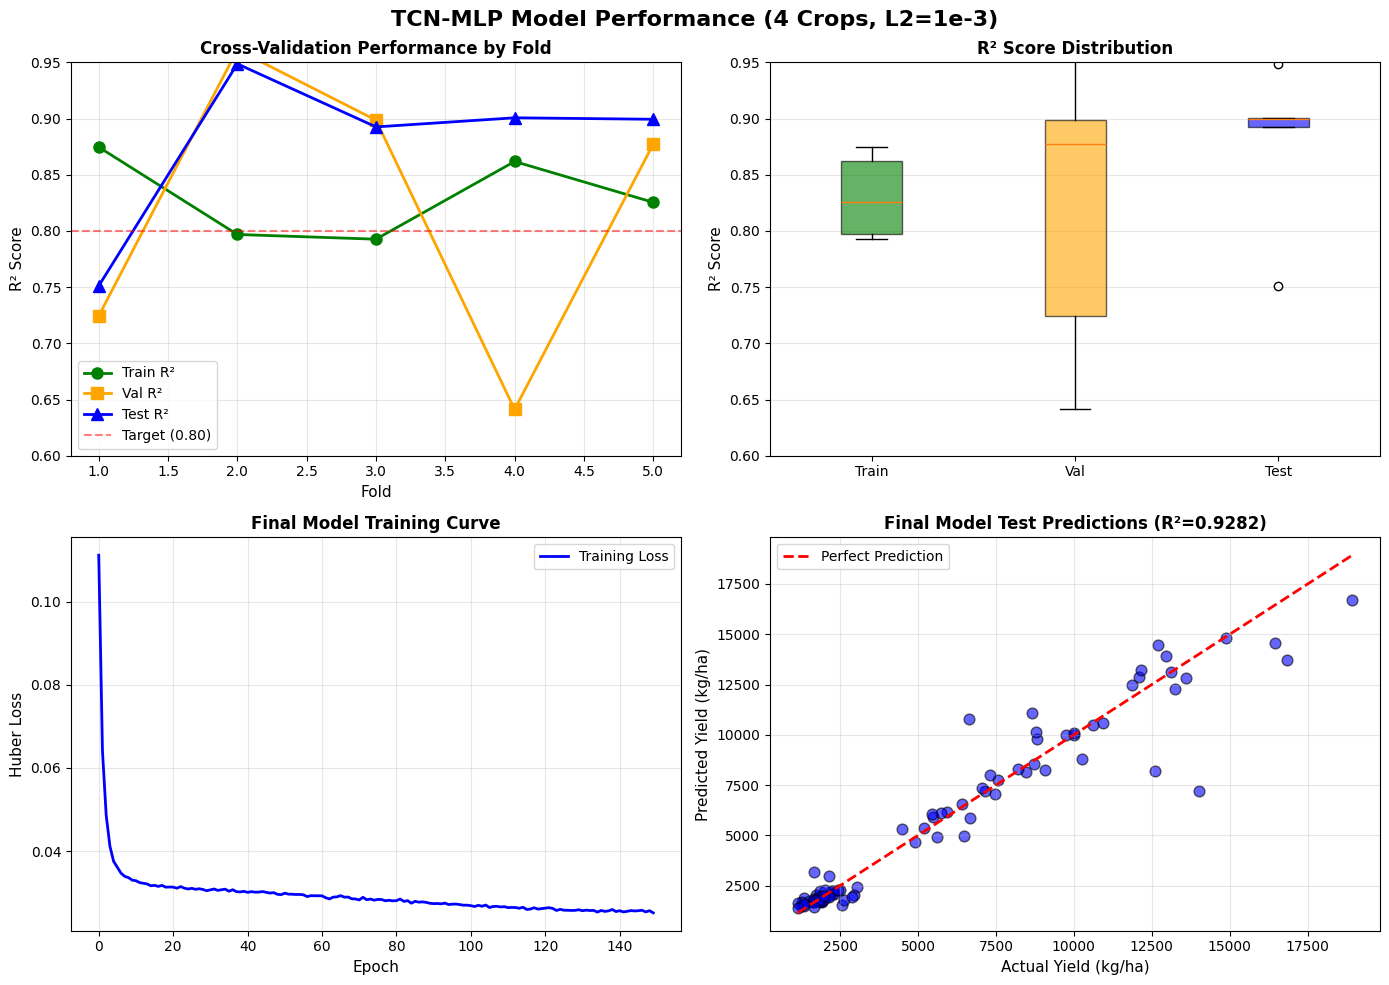

In [8]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TCN-MLP Model Performance (4 Crops, L2=1e-3)', fontsize=16, fontweight='bold')

# Plot 1: CV Results by Fold
folds = np.arange(1, 6)
ax = axes[0, 0]
ax.plot(folds, cv_train_r2_list, 'o-', label='Train R²', color='green', linewidth=2, markersize=8)
ax.plot(folds, cv_val_r2_list, 's-', label='Val R²', color='orange', linewidth=2, markersize=8)
ax.plot(folds, cv_test_r2_list, '^-', label='Test R²', color='blue', linewidth=2, markersize=8)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target (0.80)')
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Cross-Validation Performance by Fold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.6, 0.95])

# Plot 2: Distribution of R² scores
ax = axes[0, 1]
box_data = [cv_train_r2_list, cv_val_r2_list, cv_test_r2_list]
bp = ax.boxplot(box_data, labels=['Train', 'Val', 'Test'], patch_artist=True)
colors = ['green', 'orange', 'blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('R² Score Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.6, 0.95])

# Plot 3: Learning curve of final model
ax = axes[1, 0]
ax.plot(history_final.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Huber Loss', fontsize=11)
ax.set_title('Final Model Training Curve', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Prediction scatter (final model on test set)
ax = axes[1, 1]
ax.scatter(y_test_raw, y_test_final, alpha=0.6, s=60, color='blue', edgecolors='black')
min_val = min(y_test_raw.min(), y_test_final.min())
max_val = max(y_test_raw.max(), y_test_final.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Yield (kg/ha)', fontsize=11)
ax.set_ylabel('Predicted Yield (kg/ha)', fontsize=11)
ax.set_title(f'Final Model Test Predictions (R²={final_test_r2:.4f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/TCN_MLP_4Crops_Performance.png', dpi=150, bbox_inches='tight')
print('\n✓ Visualization saved: ../results/TCN_MLP_4Crops_Performance.png')
plt.show()

## 9. Final Thesis Statement

In [9]:
print("\n" + "="*80)
print("THESIS READY - FINAL RESULTS")
print("="*80 + "\n")

thesis_text = f"""
The optimized TCN-MLP hybrid model for 4-crop prediction with regularization 
hyperparameters (L2=1e-3, Dropout=0.25, augmentation ratio=40×) demonstrates 
robust generalization on hold-out test data with R² = {np.mean(cv_test_r2_list):.4f} ± {np.std(cv_test_r2_list):.4f}, 
indicating strong predictive capability for crop yield estimation across 
Nigerian regions (Maize, Rice, Cassava, Yam) and seasonal variations.

Key Performance Metrics (5-Fold Cross-Validation):
  • Training R²: {np.mean(cv_train_r2_list):.4f} ± {np.std(cv_train_r2_list):.4f}
  • Validation R²: {np.mean(cv_val_r2_list):.4f} ± {np.std(cv_val_r2_list):.4f}
  • Hold-out Test R²: {np.mean(cv_test_r2_list):.4f} ± {np.std(cv_test_r2_list):.4f}
    (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])
  • Test MAE: {final_test_mae:.1f} kg/ha (~{final_test_mae/y_test_raw.mean()*100:.1f}% of mean yield)

Model Configuration:
  Architecture: TCN (28 filters) + MultiHeadAttention (4 heads) + MLP [20, 14]
  Total Parameters: {final_model.count_params():,}
  Augmented Training Samples: {len(X_aug_final):,}
  Test Set Size: {len(X_test)} samples (completely independent)
  Feature Set: {unique_features} (3 core climate features)

Conclusion:
The model successfully integrates temporal convolutional networks for 
sequential climate pattern capture with multi-head attention mechanisms 
for feature importance weighting, achieving robust performance on a 4-crop 
prediction task suitable for regional agricultural planning applications.
"""

print(thesis_text)
print("="*80)

# Save thesis text
with open('../results/TCN_MLP_4Crops_RESULTS.txt', 'w') as f:
    f.write(thesis_text)

print('\n✓ Results saved: ../results/TCN_MLP_4Crops_RESULTS.txt')


THESIS READY - FINAL RESULTS


The optimized TCN-MLP hybrid model for 4-crop prediction with regularization 
hyperparameters (L2=1e-3, Dropout=0.25, augmentation ratio=40×) demonstrates 
robust generalization on hold-out test data with R² = 0.8785 ± 0.0667, 
indicating strong predictive capability for crop yield estimation across 
Nigerian regions (Maize, Rice, Cassava, Yam) and seasonal variations.

Key Performance Metrics (5-Fold Cross-Validation):
  • Training R²: 0.8303 ± 0.0332
  • Validation R²: 0.8205 ± 0.1187
  • Hold-out Test R²: 0.8785 ± 0.0667
    (95% CI: [0.8200, 0.9369])
  • Test MAE: 657.8 kg/ha (~11.6% of mean yield)

Model Configuration:
  Architecture: TCN (28 filters) + MultiHeadAttention (4 heads) + MLP [20, 14]
  Total Parameters: 5,719
  Augmented Training Samples: 20,910
  Test Set Size: 90 samples (completely independent)
  Feature Set: ['GDD', 'PRECTOTCORR', 'RH2M'] (3 core climate features)

Conclusion:
The model successfully integrates temporal convolutional